<a href="https://colab.research.google.com/github/PaulaEsguerra-17F/upsrj-kera-workspace/blob/main/CNN_Dog.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Red Convolucional con Keras para deteccion de perros
## Objetivo
Implementar una red neuronal convolucional que nos permita procesar imagenes para detectar a que clase pertenece, especificamente, necesitamos aprender a diferenciar entre perros y gatos.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.utils import to_categorical
from dataclasses import dataclass

1. **Cargar y preparar los datos**

Usaremos el dataset de ejemplo de [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html), el cual incluye 60000 imagenes a color de 32x32 en 10 clases, con 6000 imagenes por clase.


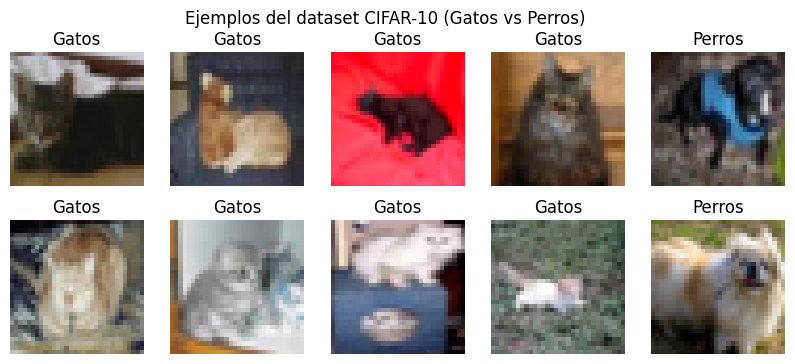

In [9]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Estructura de datos
@dataclass
class gatos:
  id: int = 3
  label: str = "Gatos"

@dataclass
class perros:
  id: int = 5
  label: str = "Perros"

deseado = perros
no_deseado = gatos

# Clases: 3 = gato, 5 = perro
mask_train = (y_train.flatten() == gatos.id) | (y_train.flatten() == perros.id)
mask_test = (y_test.flatten() == gatos.id) | (y_test.flatten() == perros.id)

# Filtramos de la base de datos las clases deseadas
x_train, y_train = x_train[mask_train], y_train[mask_train]
x_test, y_test = x_test[mask_test], y_test[mask_test]

# Normalización (0,1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Convertimos etiquetas: gato = 0, perro = 1
y_train = (y_train == deseado.id).astype(int)
y_test = (y_test == deseado.id).astype(int)

# Visualización de imágenes
fig, axes = plt.subplots(2, 5, figsize=(10,4))
for i, ax in enumerate(axes.flat):
  ax.imshow(x_train[i])
  ax.set_title(deseado.label if y_train[i] == 1 else no_deseado.label)
  ax.axis("off")
plt.suptitle(f"Ejemplos del dataset CIFAR-10 ({no_deseado.label} vs {deseado.label})")
plt.show()

2. **Ejecucion con DNN (poco eficiente)**

En este caso especifico no es eficiente utilizar un DNN para el analisis de nuestros datos, esto debido a que el formato de los datos es de imagenes de 32x32 RGB, lo cual se traducde a 3072 neuronas por imagen, lo cual dado al numero de entradas (50000) nos da en total 153,600,000 neuronas necesarias.

In [10]:
from IPython.core import history
model_dnn = Sequential()

# Input layer
model_dnn.add(Flatten(input_shape=(32,32,3)))
# Hidden layer
model_dnn.add(Dense(128, activation="relu"))
# Output layer
model_dnn.add(Dense(1, activation="sigmoid"))

# Compilamos DNN
model_dnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# Alimentamos DNN
history_dnn = model_dnn.fit(x_train, y_train, epochs=5, batch_size=64,
                            validation_data=(x_test, y_test), verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5517 - loss: 0.7571 - val_accuracy: 0.5105 - val_loss: 0.7838
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5695 - loss: 0.6867 - val_accuracy: 0.5495 - val_loss: 0.7052
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5739 - loss: 0.6853 - val_accuracy: 0.5910 - val_loss: 0.6649
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5975 - loss: 0.6652 - val_accuracy: 0.6040 - val_loss: 0.6606
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5957 - loss: 0.6631 - val_accuracy: 0.5865 - val_loss: 0.6735


3. **Ejecucion con CNN**

Dado el formato de los datos de entrada mencionados anteriormente, haremos una red neuronal convolucional (CNN) para el analisis.

In [14]:
#Model CNN
model_cnn =Sequential()

#Input layer
model_cnn.add(Conv2D(32, (3,3), activation="relu", input_shape=(32,32,3)))
#Hidden layer
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Conv2D(64, (3,3), activation="relu"))
model_cnn.add(MaxPooling2D((2,2)))
model_cnn.add(Flatten())
model_cnn.add(Dense(64, activation="relu"))
model_cnn.add(Dropout(0.5))
model_cnn.add(Dense(1, activation="relu"))
model_cnn.add(Dropout(0.5))

#Output layer
model_cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

#alimentamos CNN
history_cnn = model_cnn.fit(x_train, y_train, epochs=10, batch_size=64, validation_data=(x_test, y_test), verbose=1)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.5218 - loss: 4.8134 - val_accuracy: 0.5000 - val_loss: 0.8276
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5325 - loss: 4.4449 - val_accuracy: 0.5005 - val_loss: 0.7755
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5376 - loss: 4.4339 - val_accuracy: 0.5005 - val_loss: 0.8400
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5618 - loss: 4.3708 - val_accuracy: 0.5140 - val_loss: 0.7667
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5673 - loss: 4.5153 - val_accuracy: 0.5010 - val_loss: 0.8444
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5612 - loss: 4.5250 - val_accuracy: 0.5250 - val_loss: 0.7573
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5357 - loss: 4.4562 - val_accuracy: 0.5020 - val_loss: 0.8394
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5766 - loss: 4.2649 - val_accuracy: 0

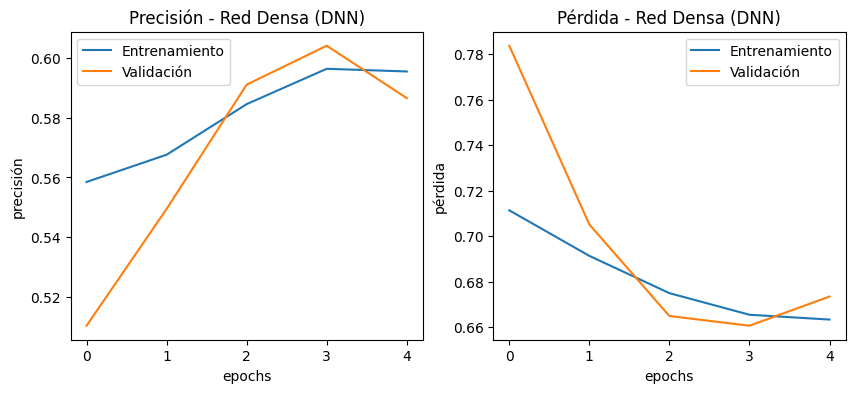

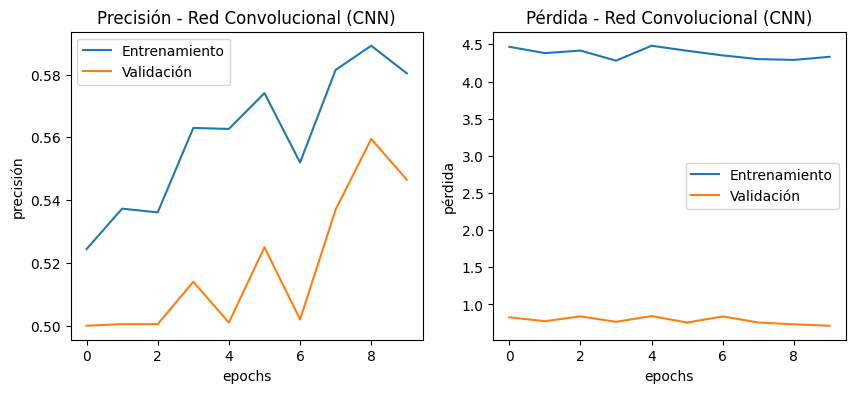

In [20]:
# Graficación de precisión y pérdida de entrenamiento
def plot_history(history, title):
  plt.figure(figsize=(10,4))
  # Precisión
  plt.subplot(1,2,1)
  plt.plot(history.history['accuracy'], label='Entrenamiento')
  plt.plot(history.history['val_accuracy'], label='Validación')
  plt.title(f'Precisión - {title}')
  plt.xlabel('epochs')
  plt.ylabel('precisión')
  plt.legend()
  # Pérdida
  plt.subplot(1,2,2)
  plt.plot(history.history['loss'], label='Entrenamiento')
  plt.plot(history.history['val_loss'], label='Validación')
  plt.title(f'Pérdida - {title}')
  plt.xlabel('epochs')
  plt.ylabel('pérdida')
  plt.legend()
  # Despliegue de gráfico
  plt.show()

plot_history(history_dnn, 'Red Densa (DNN)')
plot_history(history_cnn, 'Red Convolucional (CNN)')

In [21]:
# Evaluar resultados
print('\nEvaluacion DNN:')
model_dnn.evaluate(x_test, y_test)

print('\nEvaluacion CNN:')
model_cnn.evaluate(x_test, y_test)


Evaluacion DNN:
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5804 - loss: 0.6825

Evaluacion CNN:
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5454 - loss: 0.7152


[0.7143420577049255, 0.546500027179718]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step


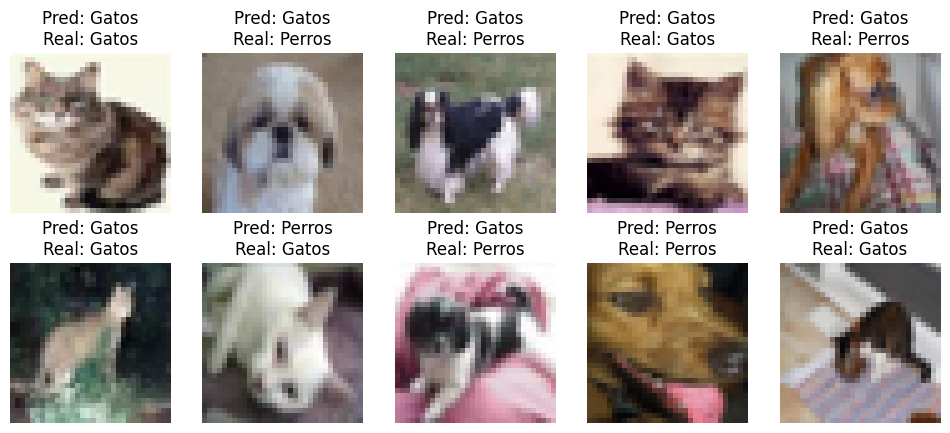

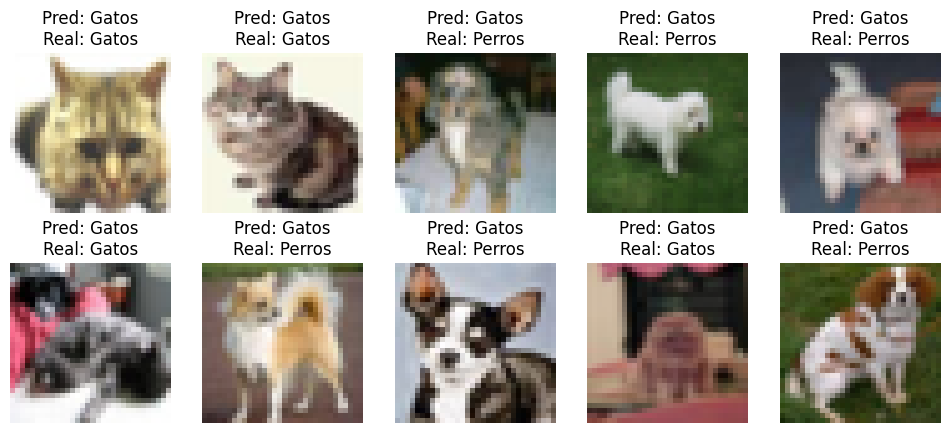

In [24]:
# visualización de algunas predicciones
def show_predictions(model, x_data, y_data, n=10, title="Predicciones"):
  idx = np.random.choice(len(x_data), n)
  preds = (model.predict(x_data[idx]) > 0.5).astype(int)
  fig, axes = plt.subplots(2, n//2, figsize=(12,5))
  for i, ax in enumerate(axes.flat):
    ax.imshow(x_data[idx[i]])
    ax.set_title(f"Pred: {deseado.label if preds[i] == 1 else no_deseado.label}\nReal: {deseado.label if y_data[idx[i]] == 1 else no_deseado.label}")
    ax.axis("off")


show_predictions(model_dnn, x_test, y_test, title="Predicciones DNN")
show_predictions(model_cnn, x_test, y_test, title="Predicciones CNN")

4. **Uso de nuestra red para una imagen propia**

**Instrucciones:** Sube una fotografia de tu mascota y comprueba si tu perro es realmente un perro segun la IA o un gato disfrazado.

In [25]:
from google.colab import files
from tensorflow.keras.preprocessing import image

# Subir imagen desde tu PC
uploaded = files.upload()

#Mostramos el nombre del archivo subido
for fn in uploaded.keys():
  img_patch = fn
  print("Archivo cargado:", img_patch)

Saving Becky.jpeg to Becky.jpeg
Archivo cargado: Becky.jpeg


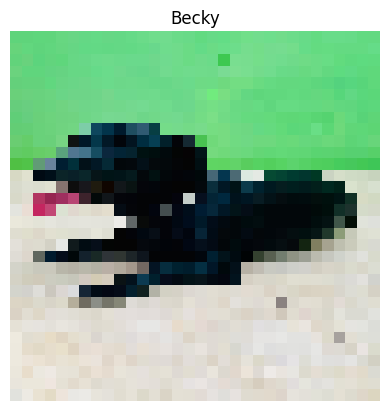

In [27]:
# Cargar y preparar la imagen
img = image.load_img(img_patch, target_size=(32,32))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0) # Forma (1, 32, 32, 3)

plt.imshow(img)
plt.title("Becky")
plt.axis("off")
plt.show()

In [28]:
# Hacer prediccion
pred = model_cnn.predict(img_array)[0][0]
label = f"Becky es un {perro.label if pred > 0.5 else gatos.label}"
print(f"Prediccion del modelo: {label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
Prediccion del modelo: Becky es un Gatos


5. **Mejora del modelo CNN para mayor precision**

Implementaremos mas capas de nuestro modelo CNN para asegurar una precision entre el 80%  y 90%.

In [30]:
from tensorflow.keras import layers, models

improved_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compilamos CNN
improved_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Alimentamos CNN
improved_history = improved_model.fit(x_train, y_train, epochs=5, batch_size=64,
                                  validation_data=(x_test, y_test), verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - accuracy: 0.5768 - loss: 0.8402 - val_accuracy: 0.5000 - val_loss: 0.6921
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6340 - loss: 0.6651 - val_accuracy: 0.6685 - val_loss: 0.6617
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7000 - loss: 0.5789 - val_accuracy: 0.6585 - val_loss: 0.6120
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7358 - loss: 0.5298 - val_accuracy: 0.7495 - val_loss: 0.5223
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7655 - loss: 0.4872 - val_accuracy: 0.7080 - val_loss: 0.5708


Saving Bigotes.jpeg to Bigotes.jpeg
Archivo cargado: Bigotes.jpeg


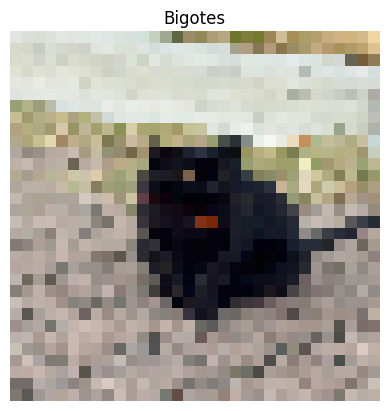

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Predicción del modelo: Bigotes es un Gatos


In [38]:
# subir imagen desde tu PC
uploaded = files.upload()

# Mostramos el nombre del archivo subido
for fn in uploaded.keys():
  img_path = fn
  print("Archivo cargado:", img_path)

# cargar y preparar la imagen
img = image.load_img(img_path, target_size=(32, 32))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0) # forma (1, 32, 32, 3)

plt.imshow(img)
plt.title("Bigotes")
plt.axis("off")
plt.show()

# hacer predicción
pred = improved_model.predict(img_array)[0][0]
label = f"Bigotes es un {perros.label if pred > 0.5 else gatos.label}"
print(f"Predicción del modelo: {label}")